# LSTM Sentiment Analysis - Simple Practical

**Aim:** Classify movie reviews as Positive or Negative using an LSTM network.

Nitheeswaran M  24BAD079

## Part A - Dataset Preparation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000      # Use the 10,000 most common words
max_length = 200        # Each review will have 200 word IDs

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training reviews:", len(x_train))
print("Testing reviews:", len(x_test))
print("First review word IDs:", x_train[0][:20])
print("First review sentiment:", "Positive" if y_train[0] == 1 else "Negative")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training reviews: 25000
Testing reviews: 25000
First review word IDs: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First review sentiment: Positive


In [2]:
# Convert word IDs back to words to see a sample review
word_index = imdb.get_word_index() 
index_word = {value + 3: key for key, value in word_index.items()}

sample_review = " ".join(index_word.get(i, "?") for i in x_train[0] if i > 3)
print("Sample review:", sample_review[:600], "...")
print("Label:", "Positive" if y_train[0] else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample review: this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they s ...
Label: Positive


In [3]:
# Pad short reviews and shorten long reviews to 200 words
x_train = pad_sequences(x_train, maxlen=max_length, padding="post", truncating="post")
x_test = pad_sequences(x_test, maxlen=max_length, padding="post", truncating="post")

# Keep 5,000 training reviews for validation
x_val, y_val = x_train[-5000:], y_train[-5000:]
x_train, y_train = x_train[:-5000], y_train[:-5000]

print("Train shape:", x_train.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)
print("Nitheeswaran M 24BAD079")

Train shape: (20000, 200)
Validation shape: (5000, 200)
Test shape: (25000, 200)
Nitheeswaran M 24BAD079


## Part B - Build the LSTM Model

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()
print("Nitheeswaran M 24BAD079")

I0000 00:00:1791559907.149642      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791559907.153501      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Nitheeswaran M 24BAD079


## Part C - Train and Evaluate

In [5]:
history = model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7443 - loss: 0.5042 - val_accuracy: 0.8542 - val_loss: 0.3605
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8866 - loss: 0.2924 - val_accuracy: 0.8712 - val_loss: 0.3184
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9220 - loss: 0.2151 - val_accuracy: 0.8752 - val_loss: 0.3388


In [6]:
# Training and validation accuracy / loss for each epoch
for i in range(len(history.history["accuracy"])):
    print(f"Epoch {i+1}: Train Acc={history.history['accuracy'][i]:.3f}, "
          f"Val Acc={history.history['val_accuracy'][i]:.3f}, "
          f"Train Loss={history.history['loss'][i]:.3f}, "
          f"Val Loss={history.history['val_loss'][i]:.3f}")

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {accuracy:.3f}")
print(f"Test loss: {loss:.3f}")

Epoch 1: Train Acc=0.744, Val Acc=0.854, Train Loss=0.504, Val Loss=0.361
Epoch 2: Train Acc=0.887, Val Acc=0.871, Train Loss=0.292, Val Loss=0.318
Epoch 3: Train Acc=0.922, Val Acc=0.875, Train Loss=0.215, Val Loss=0.339

Test accuracy: 0.850
Test loss: 0.384


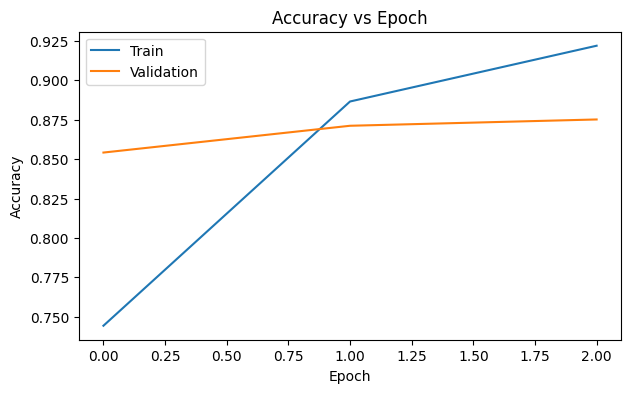

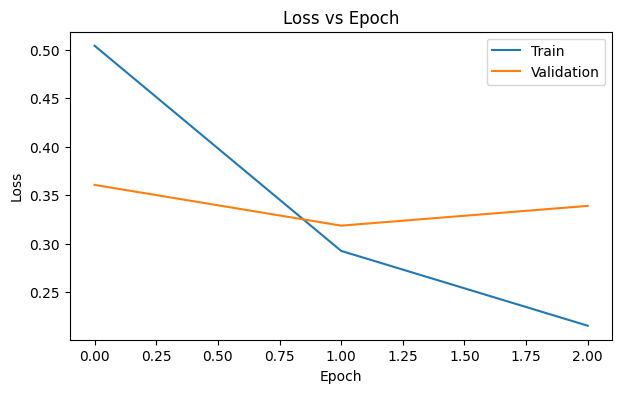

In [7]:
# Plot accuracy and loss
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Accuracy: 0.85
Precision: 0.861
Recall: 0.834
F1-score: 0.848


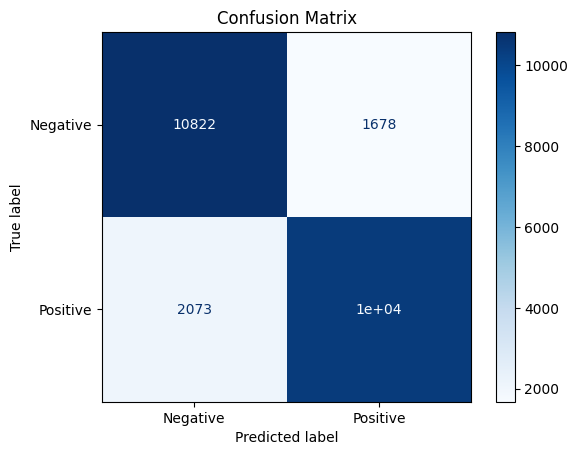

Nitheeswaran M 24BAD079


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

probabilities = model.predict(x_test, verbose=0).flatten()
y_pred = (probabilities >= 0.5).astype(int)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1-score:", round(f1_score(y_test, y_pred), 3))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
print("Nitheeswaran M 24BAD079")

## Part D - Predict New Reviews

In [9]:
def predict_sentiment(review):
    # Lowercase and split into words
    words = re.findall(r"[a-z']+", review.lower())

    # IMDB word IDs are shifted by 3; ID 2 means unknown word
    numbers = [1] + [word_index.get(word, -1) + 3
                     if word_index.get(word, -1) + 3 < vocab_size and word in word_index
                     else 2 for word in words]

    # Use same padding as training
    padded = pad_sequences([numbers], maxlen=max_length,
                           padding="post", truncating="post")
    probability = float(model.predict(padded, verbose=0)[0][0])
    sentiment = "Positive" if probability >= 0.5 else "Negative"
    return sentiment, probability

reviews = [
    ("This movie was wonderful and the acting was amazing", "Positive"),
    ("The film was boring and I hated the story", "Negative"),
    ("An excellent story with fantastic performances", "Positive"),
    ("Terrible movie and a complete waste of time", "Negative")
]

for review, expected in reviews:
    predicted, probability = predict_sentiment(review)
    print("Review:", review)
    print("Expected:", expected, "| Predicted:", predicted,
          "| Positive probability:", round(probability, 3))
    print("Correct:", expected == predicted)
    print()

print("Nitheeswaran M 24BAD079")

Review: This movie was wonderful and the acting was amazing
Expected: Positive | Predicted: Positive | Positive probability: 0.852
Correct: True

Review: The film was boring and I hated the story
Expected: Negative | Predicted: Negative | Positive probability: 0.183
Correct: True

Review: An excellent story with fantastic performances
Expected: Positive | Predicted: Positive | Positive probability: 0.894
Correct: True

Review: Terrible movie and a complete waste of time
Expected: Negative | Predicted: Negative | Positive probability: 0.057
Correct: True

Nitheeswaran M 24BAD079
